In [70]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# XGBoost model (powerful boosting algorithm)
from xgboost import XGBClassifier

# STEP 1 — Load Data

In [71]:
# 📌 Check missing values in all datasets
print("Heart Missing Values:\n", heart.isnull().sum().sum())
print("\nDiabetes Missing Values:\n", diabetes.isnull().sum().sum())
print("\nBreast Cancer Missing Values:\n", breast.isnull().sum().sum())

Heart Missing Values:
 0

Diabetes Missing Values:
 0

Breast Cancer Missing Values:
 0


# 🫀 Heart Disease

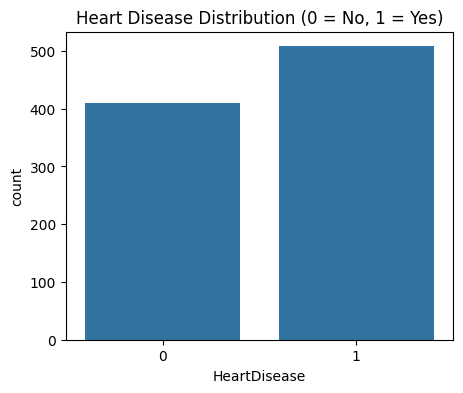

In [72]:
plt.figure(figsize=(5,4))
sns.countplot(x=heart["HeartDisease"])
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

# 🩸 Diabetes

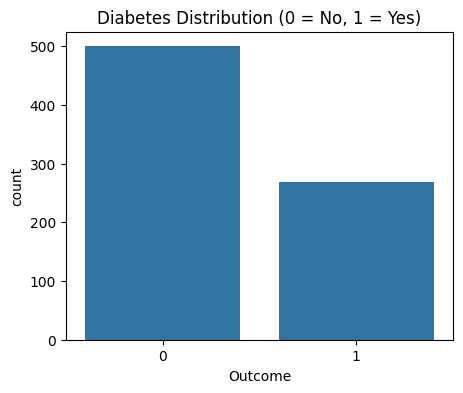

In [73]:
plt.figure(figsize=(5,4))
sns.countplot(x=diabetes["Outcome"])
plt.title("Diabetes Distribution (0 = No, 1 = Yes)")
plt.show()

# STEP 2 — EDA (Understanding the Data)

# 🎗 Breast Cancer

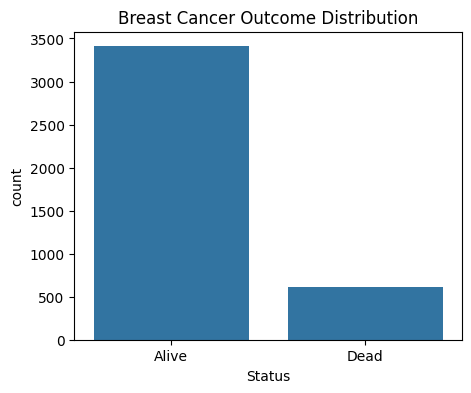

In [74]:
# Status: Alive / Dead
plt.figure(figsize=(5,4))
sns.countplot(x=breast["Status"])
plt.title("Breast Cancer Outcome Distribution")
plt.show()

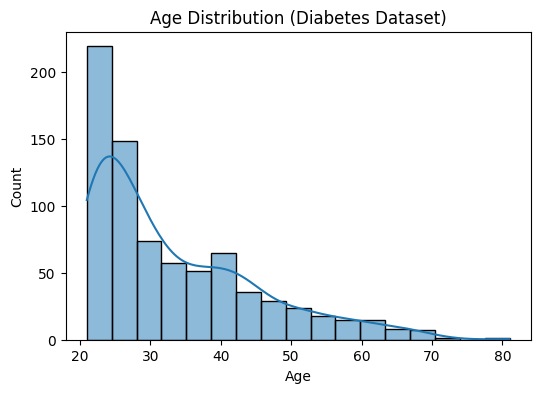

In [75]:
plt.figure(figsize=(6,4))
sns.histplot(diabetes["Age"], kde=True)
plt.title("Age Distribution (Diabetes Dataset)")
plt.show()

**📌 BMI distribution**

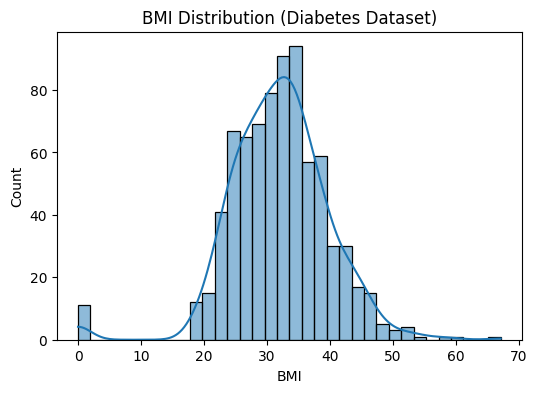

In [76]:
plt.figure(figsize=(6,4))
sns.histplot(diabetes["BMI"], kde=True)
plt.title("BMI Distribution (Diabetes Dataset)")
plt.show()

# 🫀 3.2 Heart Dataset — Feature Insight
**📌 Age distribution**

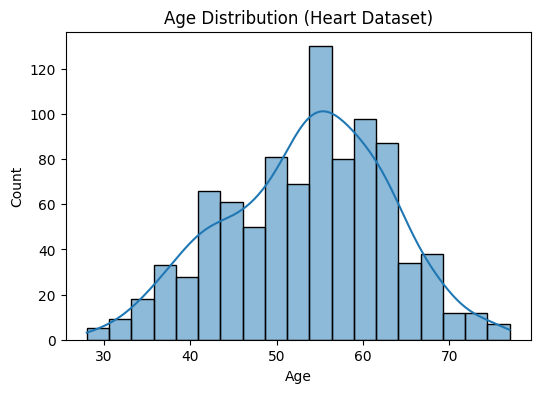

In [77]:
plt.figure(figsize=(6,4))
sns.histplot(heart["Age"], kde=True)
plt.title("Age Distribution (Heart Dataset)")
plt.show()

**📌 Cholesterol (risk indicator)**

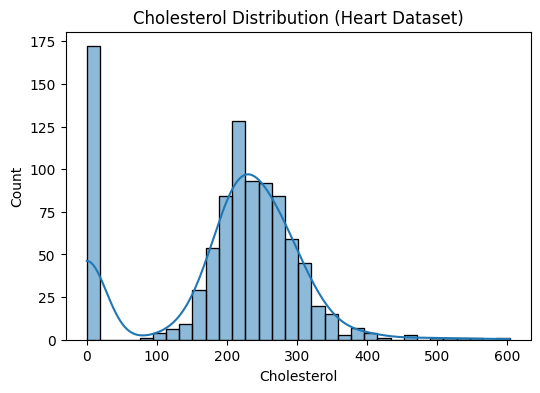

In [78]:
plt.figure(figsize=(6,4))
sns.histplot(heart["Cholesterol"], kde=True)
plt.title("Cholesterol Distribution (Heart Dataset)")
plt.show()

# 🎗 3.3 Breast Cancer — Medical Features
**📌 Tumor Size (VERY IMPORTANT)**

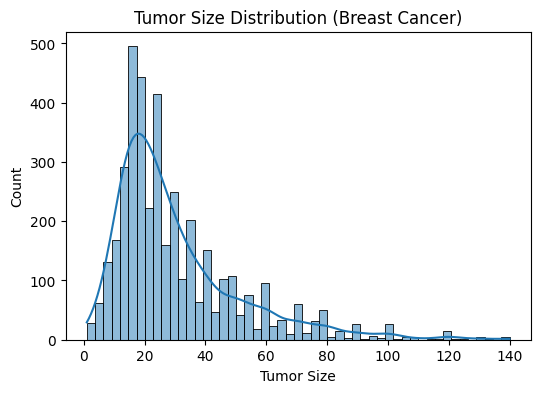

In [79]:
plt.figure(figsize=(6,4))
sns.histplot(breast["Tumor Size"], kde=True)
plt.title("Tumor Size Distribution (Breast Cancer)")
plt.show()

**📌 Survival Months**

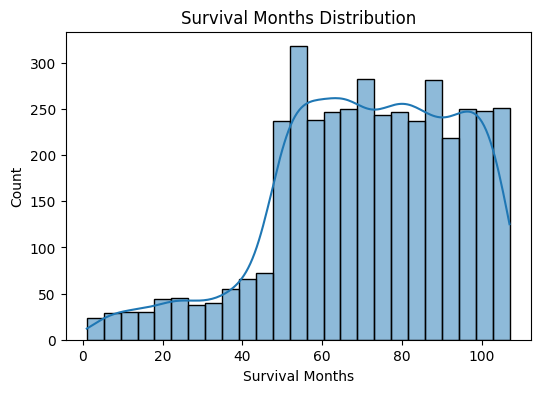

In [80]:
plt.figure(figsize=(6,4))
sns.histplot(breast["Survival Months"], kde=True)
plt.title("Survival Months Distribution")
plt.show()

# 📊 3.4 Correlation Heatmap
**🧠 Diabetes correlations**

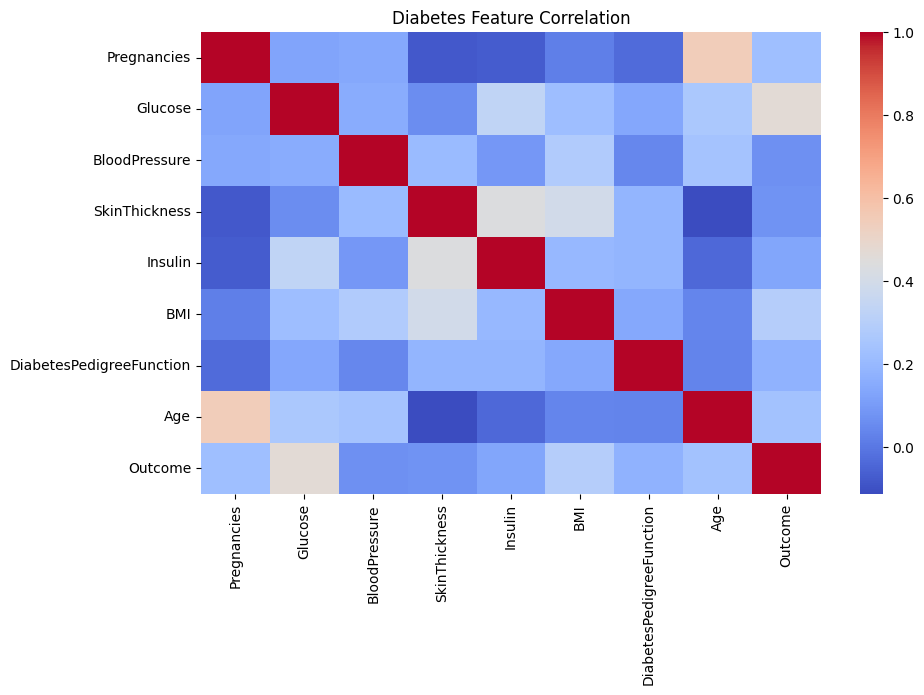

In [81]:
plt.figure(figsize=(10,6))
sns.heatmap(diabetes.corr(), cmap="coolwarm")
plt.title("Diabetes Feature Correlation")
plt.show()

**🫀 Heart correlations**

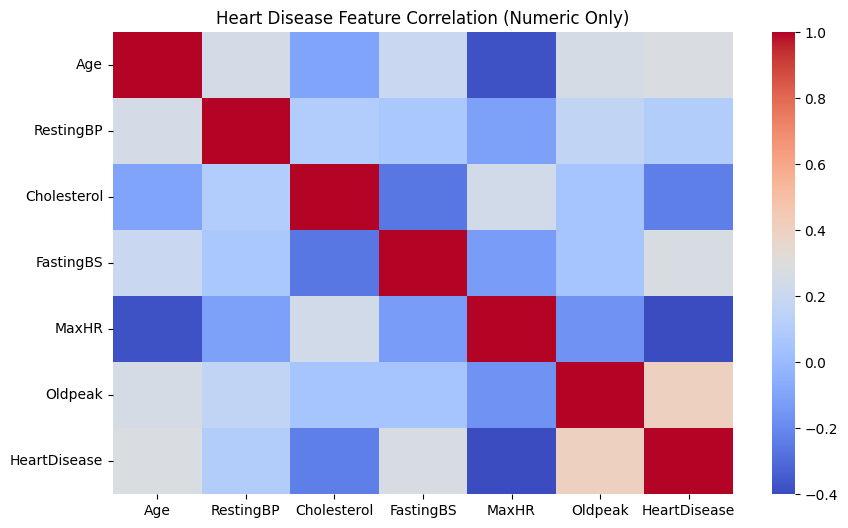

In [82]:
# 📌 Select only numeric columns
heart_numeric = heart.select_dtypes(include=["int64", "float64"])

# 📊 Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(heart_numeric.corr(), cmap="coolwarm")
plt.title("Heart Disease Feature Correlation (Numeric Only)")
plt.show()

**🎗 Breast Cancer correlations**

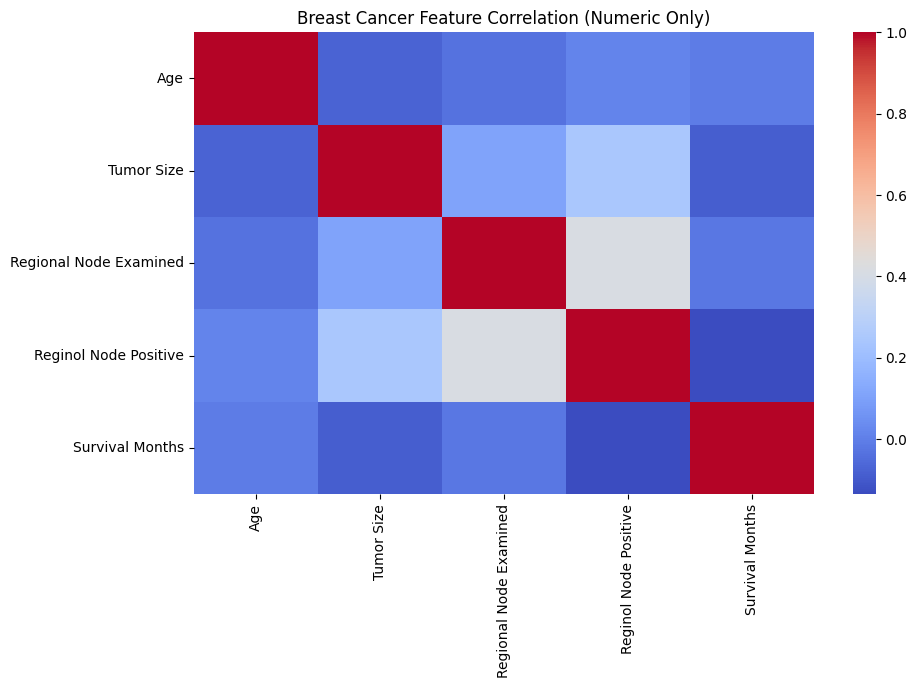

In [83]:
# 📌 Select only numeric columns
breast_numeric = breast.select_dtypes(include=["int64", "float64"])

# 📊 Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(breast_numeric.corr(), cmap="coolwarm")
plt.title("Breast Cancer Feature Correlation (Numeric Only)")
plt.show()

# 🧹 STEP 4 — DATA CLEANING + ENCODING

# 🫀 4.1 Heart Dataset — Encoding
**📌 We encode categorical columns**

In [84]:
# Copy dataset to avoid overwriting original
heart_encoded = heart.copy()

# Identify categorical columns
categorical_cols = heart_encoded.select_dtypes(include=["object"]).columns

print("Categorical columns in Heart dataset:", categorical_cols)

# Apply One-Hot Encoding
# Convert categorical features into numeric
heart_encoded = pd.get_dummies(heart_encoded, columns=categorical_cols)

print("New Heart shape after encoding:", heart_encoded.shape)
display(heart_encoded.head())

Categorical columns in Heart dataset: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')
New Heart shape after encoding: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


# 🎗 4.2 Breast Cancer Dataset — Already partially encoded

In [85]:
# Copy dataset
breast_encoded = breast.copy()

# Encode target first (if not already done)
breast_encoded["Status"] = breast_encoded["Status"].map({"Alive": 0, "Dead": 1})

# Encode categorical columns
categorical_cols = breast_encoded.select_dtypes(include=["object"]).columns

print("Remaining categorical columns:", categorical_cols)

breast_encoded = pd.get_dummies(breast_encoded, columns=categorical_cols)

print("Breast Cancer shape after encoding:", breast_encoded.shape)
display(breast_encoded.head())

Remaining categorical columns: Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status'],
      dtype='object')
Breast Cancer shape after encoding: (4024, 40)


,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Race_Black,Race_Other,Race_White,Marital Status_Divorced,...,Grade_ anaplastic; Grade IV,Grade_1,Grade_2,Grade_3,A Stage_Distant,A Stage_Regional,Estrogen Status_Negative,Estrogen Status_Positive,Progesterone Status_Negative,Progesterone Status_Positive
0,68,4,24,1,60,0,False,False,True,False,...,False,False,False,True,False,True,False,True,False,True
1,50,35,14,5,62,0,False,False,True,False,...,False,False,True,False,False,True,False,True,False,True
2,58,63,14,7,75,0,False,False,True,True,...,False,False,True,False,False,True,False,True,False,True
3,58,18,2,1,84,0,False,False,True,False,...,False,False,False,True,False,True,False,True,False,True
4,47,41,3,1,50,0,False,False,True,False,...,False,False,False,True,False,True,False,True,False,True


# 🩸 4.3 Diabetes Dataset

In [86]:
# Diabetes dataset is already numeric
print("Diabetes data types:\n", diabetes.dtypes)

print("FINAL DATA SHAPES AFTER ENCODING:")
print("Heart:", heart_encoded.shape)
print("Diabetes:", diabetes.shape)
print("Breast Cancer:", breast_encoded.shape)

Diabetes data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
FINAL DATA SHAPES AFTER ENCODING:
Heart: (918, 21)
Diabetes: (768, 9)
Breast Cancer: (4024, 40)


# ⚖️ STEP 5 — FEATURE SCALING + TRAIN/TEST SPLIT (CLEAN STRUCTURE)

**HEART DATASET PREPROCESSING**

In [87]:
# ================================
# 🫀 HEART DATASET PREPROCESSING
# ================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X_heart = heart_encoded.drop("HeartDisease", axis=1)
y_heart = heart_encoded["HeartDisease"]

# Train-test split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

# Scaling (important for SVM + Logistic Regression)
scaler_h = StandardScaler()
Xh_train = scaler_h.fit_transform(Xh_train)
Xh_test = scaler_h.transform(Xh_test)

print("✔ Heart dataset ready")
print("Train shape:", Xh_train.shape)
print("Test shape:", Xh_test.shape)

✔ Heart dataset ready
Train shape: (734, 20)
Test shape: (184, 20)


**DIABETES DATASET**

In [88]:
# ================================
# 🩸 DIABETES DATASET PREPROCESSING
# ================================

# Split features and target
X_diabetes = diabetes.drop("Outcome", axis=1)
y_diabetes = diabetes["Outcome"]

# Train-test split
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# Scaling (VERY IMPORTANT for this dataset)
scaler_d = StandardScaler()
Xd_train = scaler_d.fit_transform(Xd_train)
Xd_test = scaler_d.transform(Xd_test)

print("✔ Diabetes dataset ready")
print("Train shape:", Xd_train.shape)
print("Test shape:", Xd_test.shape)

✔ Diabetes dataset ready
Train shape: (614, 8)
Test shape: (154, 8)


# 🎗 BREAST CANCER DATASET

In [89]:
# ================================
# 🎗 BREAST CANCER DATASET PREPROCESSING
# ================================

# Split features and target
X_breast = breast_encoded.drop("Status", axis=1)
y_breast = breast_encoded["Status"]

# Train-test split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_breast, y_breast, test_size=0.2, random_state=42
)

# Scaling
scaler_b = StandardScaler()
Xb_train = scaler_b.fit_transform(Xb_train)
Xb_test = scaler_b.transform(Xb_test)

print("✔ Breast Cancer dataset ready")
print("Train shape:", Xb_train.shape)
print("Test shape:", Xb_test.shape)

✔ Breast Cancer dataset ready
Train shape: (3219, 39)
Test shape: (805, 39)


# 🫀 STEP 6 — MODEL TRAINING + COMPARISON (HEART DATASET)

In [96]:
# ================================
# 🫀 HEART - TRAIN + EVAL + SAVE
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib

# Models
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

heart_scores = {}
heart_models_saved = {}

for name, model in models.items():
    # Train
    model.fit(Xh_train, yh_train)
    
    # Predict
    preds = model.predict(Xh_test)
    
    # Score
    acc = accuracy_score(yh_test, preds)
    heart_scores[name] = acc
    
    # Save model
    filename = f"heart_{name}.pkl"
    joblib.dump(model, filename)
    heart_models_saved[name] = filename
    
    print(f"{name} Accuracy: {acc:.4f} | Saved: {filename}")

LogReg Accuracy: 0.8533 | Saved: heart_LogReg.pkl
SVM Accuracy: 0.8913 | Saved: heart_SVM.pkl
RandomForest Accuracy: 0.8696 | Saved: heart_RandomForest.pkl
XGBoost Accuracy: 0.8750 | Saved: heart_XGBoost.pkl


# 🩸 STEP 7 — MODEL TRAINING + COMPARISON (DIABETES DATASET)

In [97]:
# ================================
# 🩸 DIABETES - TRAIN + EVAL + SAVE
# ================================

diabetes_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

diabetes_scores = {}
diabetes_models_saved = {}

for name, model in diabetes_models.items():
    model.fit(Xd_train, yd_train)
    preds = model.predict(Xd_test)
    
    acc = accuracy_score(yd_test, preds)
    diabetes_scores[name] = acc
    
    filename = f"diabetes_{name}.pkl"
    joblib.dump(model, filename)
    diabetes_models_saved[name] = filename
    
    print(f"{name} Accuracy: {acc:.4f} | Saved: {filename}")

LogReg Accuracy: 0.7532 | Saved: diabetes_LogReg.pkl
SVM Accuracy: 0.7338 | Saved: diabetes_SVM.pkl
RandomForest Accuracy: 0.7468 | Saved: diabetes_RandomForest.pkl
XGBoost Accuracy: 0.7208 | Saved: diabetes_XGBoost.pkl


# 🎗 STEP 8 — MODEL TRAINING + COMPARISON (BREAST CANCER DATASET)

In [98]:
# ================================
# 🎗 BREAST - TRAIN + EVAL + SAVE
# ================================

breast_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

breast_scores = {}
breast_models_saved = {}

for name, model in breast_models.items():
    model.fit(Xb_train, yb_train)
    preds = model.predict(Xb_test)
    
    acc = accuracy_score(yb_test, preds)
    breast_scores[name] = acc
    
    filename = f"breast_{name}.pkl"
    joblib.dump(model, filename)
    breast_models_saved[name] = filename
    
    print(f"{name} Accuracy: {acc:.4f} | Saved: {filename}")

LogReg Accuracy: 0.8994 | Saved: breast_LogReg.pkl
SVM Accuracy: 0.8894 | Saved: breast_SVM.pkl
RandomForest Accuracy: 0.9093 | Saved: breast_RandomForest.pkl
XGBoost Accuracy: 0.8969 | Saved: breast_XGBoost.pkl


# 📊 FINAL COMPARISON TABLE

In [99]:
import pandas as pd

results = pd.DataFrame({
    "Heart": heart_scores,
    "Diabetes": diabetes_scores,
    "Breast": breast_scores
})

print("📊 FINAL ACCURACY COMPARISON")
display(results)

📊 FINAL ACCURACY COMPARISON


,Heart,Diabetes,Breast
LogReg,0.853261,0.753247,0.899379
SVM,0.891304,0.733766,0.889441
RandomForest,0.869565,0.746753,0.909317
XGBoost,0.875000,0.720779,0.896894


# 📊 STEP 9 — MODEL EVALUATION VISUALIZATION

**UNIFIED MODEL COMPARISON**

📊 Final Model Comparison Table


,Heart,Diabetes,Breast Cancer
LogReg,0.853261,0.753247,0.899379
SVM,0.891304,0.733766,0.889441
RandomForest,0.869565,0.746753,0.909317
XGBoost,0.875000,0.720779,0.896894


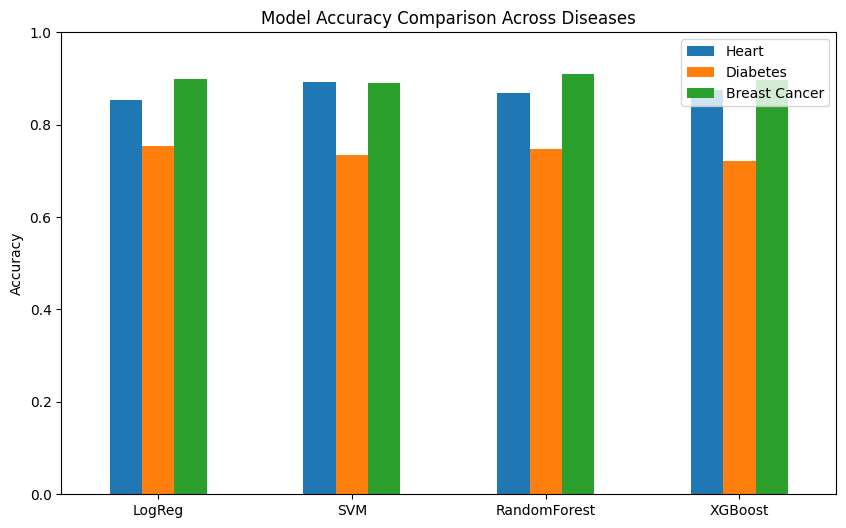

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all results
results_df = pd.DataFrame({
    "Heart": heart_scores,
    "Diabetes": diabetes_scores,
    "Breast Cancer": breast_scores
})

print("📊 Final Model Comparison Table")
display(results_df)

# Plot comparison
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Accuracy Comparison Across Diseases")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

**BEST MODEL PER DISEASE**

In [101]:
best_heart = max(heart_scores, key=heart_scores.get)
best_diabetes = max(diabetes_scores, key=diabetes_scores.get)
best_breast = max(breast_scores, key=breast_scores.get)

print("🏆 Best Models:")
print("Heart Disease:", best_heart)
print("Diabetes:", best_diabetes)
print("Breast Cancer:", best_breast)

🏆 Best Models:
Heart Disease: SVM
Diabetes: LogReg
Breast Cancer: RandomForest


**DETAILED VISUAL INSIGHT (PER DISEASE)**

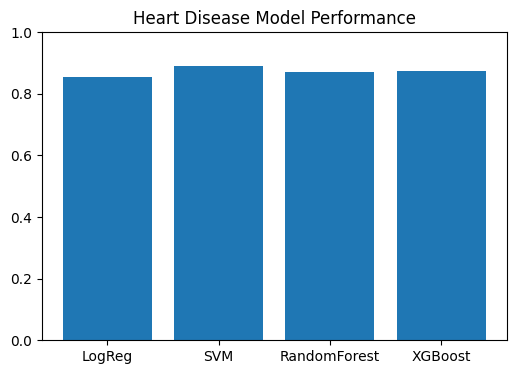

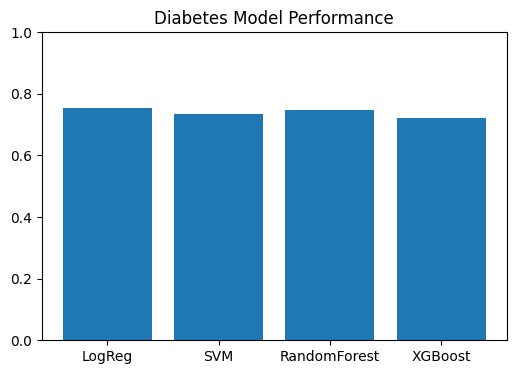

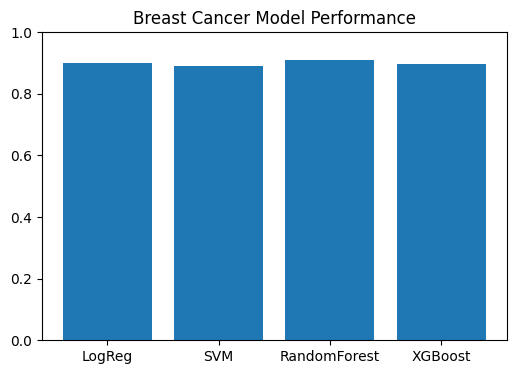

In [102]:
plt.figure(figsize=(6,4))
plt.bar(heart_scores.keys(), heart_scores.values())
plt.title("Heart Disease Model Performance")
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(diabetes_scores.keys(), diabetes_scores.values())
plt.title("Diabetes Model Performance")
plt.ylim(0,1)
plt.show()


plt.figure(figsize=(6,4))
plt.bar(breast_scores.keys(), breast_scores.values())
plt.title("Breast Cancer Model Performance")
plt.ylim(0,1)
plt.show()